# GSA - 300 Aquisição de Dados Digitais e Inteligência Artificial em Geociências (2025)

## Introdução

Como um dos métodos mais importantes para o desenveolvimento do conhecimento humano, o mapeamento geológico é de fundamental importância a execução de uma enorme varidade de atividades humanas desde qualquer uso e ocupação do solo, como na propecção de minerais essenciais para a manutenção e avanço da sociedade. O Brasil possui um território continental e grande parte desta área possui uma densa cobertura vegetal que dificulta dsecrição de rochas aflorantes tanto tanto in situ qunato por métodos de aquisição de dados remota, com isso a utilização técnicas de aprendizagem de máquina para segmentar e, ou, classificar dados contínuos e regularmente espaçados, segundo Ting Pan;

 que atende aos multiplos critérios para a execução deste método é a área coberta pela folha cartográfica de código SB.21-Z-A-II-1-NE

fid: 4198
id_folha: SB21_ZA_II1_NE
EPSG: 32721

"A principal inovação nesse tipo de produto cartográfico com relação à categoria 9 é a introdução no mapeamento geológico da tecnologia SIG ou Sistema de Informações Geográficas, de forma sistemática, cuja estruturação está respaldada em"

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# parâmetros de conexão
pg_user = "postgres"      # Login
pg_pass = "postgres"      # *****
pg_host = "localhost"     # ou "geodb.duckdns.org" no futuro quando eu ativar o tunelamento
pg_port = "5432"          # porta de acesso ao  POSTGRESQL
pg_db   = "geologia"      # Nome do banco de dados

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
)

# -------------------------------------------------------
# 1) Definir folhas e montar lista para o SQL
# -------------------------------------------------------
folhas = [
    "SB21_ZA_II1",
    "SB21_ZA_II2",
    "SB21_XC_V4",
    "SB21_XC_V3",

    # ...
]
lista_folhas_sql = ", ".join(f"'{f}'" for f in folhas)

# -------------------------------------------------------
# 2) DataFrame com amostras + litologia + identificação da folha
#    x, y em coordenadas projetadas (EPSG da própria folha)
# -------------------------------------------------------
sql_amostras = f"""
WITH folhas AS (
    SELECT
        codigo,
        escala,
        epsg,
        geom
    FROM carto.folhas_cartograficas
    WHERE codigo IN ({lista_folhas_sql})
)
SELECT
    -- identificação da folha cartográfica
    f.codigo AS folha_codigo,
    f.escala AS folha_escala,
    f.epsg   AS folha_epsg,

    -- atributos da amostra gama
    g.sample_id,
    g.survey_id,
    g.line_id,
    g.fiducial,
    g.date_local,
    g.time_local,

    -- coordenadas projetadas coerentes com a folha (recalculadas)
    ST_X(ST_Transform(g.geom, f.epsg)) AS x,
    ST_Y(ST_Transform(g.geom, f.epsg)) AS y,

    -- coordenadas geográficas originais
    g.lon, g.lat,

    g.gps_alt, g.baro_alt, g.altura,
    g.mdt, g.ctb, g.kb, g.ub, g.thb,
    g.uup, g.live_time, g.cosmico, g.temp,
    g.ctcor, g.kcor, g.ucor, g.thcor, g.ctexp,
    g.kperc, g.eu, g.eth,
    g.thk_razao, g.uk_razao, g.uth_razao,
    g.geom AS geom_ponto,

    -- atributos da litologia 100k
    l.fid        AS lit_fid,
    l.id_unidade AS lit_id_unidade,
    l.sigla      AS lit_sigla,
    l.nome       AS lit_nome,
    l.legenda    AS lit_legenda,
    l.litotipos  AS lit_litotipos,
    l.escala     AS lit_escala,
    l.mapa       AS lit_mapa,
    l.eon_min, l.eon_max,
    l.era_min, l.era_max,
    l.sistema_mi, l.sistema_ma,
    l.epoca_min, l.epoca_max,
    l.geom       AS geom_lito

FROM geof.ag_sample_gamma AS g
JOIN folhas AS f
  ON ST_Intersects(g.geom, f.geom)
LEFT JOIN litologia.litologia_100k AS l
  ON ST_Intersects(g.geom, l.geom);
"""

df_folha_lito = pd.read_sql(sql_amostras, engine)

# -------------------------------------------------------
# 3) BBoxes projetadas: TOTAL + uma por folha (mesmo EPSG da folha)
#    regions[0] = TOTAL; regions[1:] = por folha
#    (usa coluna 'ord' para ordenar sem erro no UNION)
# -------------------------------------------------------
sql_regions = f"""
WITH folhas_proj AS (
    SELECT
        codigo,
        ST_Envelope(ST_Transform(geom, epsg)) AS geom_proj
    FROM carto.folhas_cartograficas
    WHERE codigo IN ({lista_folhas_sql})
),
bbox_each AS (
    SELECT
        codigo,
        ST_XMin(geom_proj) AS x_min,
        ST_XMax(geom_proj) AS x_max,
        ST_YMin(geom_proj) AS y_min,
        ST_YMax(geom_proj) AS y_max
    FROM folhas_proj
),
bbox_total AS (
    SELECT
        'TOTAL'::text AS codigo,
        MIN(x_min) AS x_min,
        MAX(x_max) AS x_max,
        MIN(y_min) AS y_min,
        MAX(y_max) AS y_max
    FROM bbox_each
),
uniao AS (
    SELECT
        0 AS ord,
        codigo,
        x_min,
        x_max,
        y_min,
        y_max
    FROM bbox_total
    UNION ALL
    SELECT
        1 AS ord,
        codigo,
        x_min,
        x_max,
        y_min,
        y_max
    FROM bbox_each
)
SELECT
    codigo,
    x_min,
    x_max,
    y_min,
    y_max
FROM uniao
ORDER BY ord, codigo;
"""

df_regions = pd.read_sql(sql_regions, engine)

regions = [
    [
        np.float64(row["x_min"]),
        np.float64(row["x_max"]),
        np.float64(row["y_min"]),
        np.float64(row["y_max"]),
    ]
    for _, row in df_regions.iterrows()
]

codigos = df_regions["codigo"].tolist()      # ['TOTAL', 'SB21_ZA_II1_NE', ...]
region_total = regions[0]                    # bbox total
regions_por_folha = dict(zip(codigos[1:], regions[1:]))

# Objetos finais:
# - df_folha_lito: DataFrame com amostras + litologia + folha_codigo
# - region_total: [x_min_total, x_max_total, y_min_total, y_max_total]
# - regions_por_folha[folha_codigo]: region de cada folha selecionada


In [2]:
df_folha_lito.describe().T

,count,mean,std,min,25%,50%,75%,max
folha_epsg,80339.0,3.272100e+04,0.000000,3.272100e+04,3.272100e+04,3.272100e+04,3.272100e+04,3.272100e+04
sample_id,80339.0,7.196092e+05,401542.009995,5.134900e+04,3.469175e+05,6.947290e+05,1.042914e+06,1.390908e+06
survey_id,80339.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
line_id,80339.0,3.876395e+02,51.281336,3.010000e+02,3.410000e+02,3.940000e+02,4.280000e+02,4.690000e+02
fiducial,80339.0,7.208423e+03,3879.091935,2.500000e+03,3.655000e+03,6.093000e+03,9.775000e+03,1.700900e+04
x,80339.0,5.829901e+05,15892.967795,5.553933e+05,5.694223e+05,5.829477e+05,5.964420e+05,6.104627e+05
y,80339.0,9.336792e+06,15931.029419,9.309066e+06,9.322986e+06,9.336907e+06,9.350561e+06,9.364394e+06
lon,80339.0,-5.625013e+01,0.143596,-5.649953e+01,-5.637279e+01,-5.625032e+01,-5.612843e+01,-5.600173e+01
lat,80339.0,-5.999498e+00,0.144104,-6.249998e+00,-6.124394e+00,-5.998478e+00,-5.874916e+00,-5.750005e+00
gps_alt,80339.0,3.101091e+02,62.918621,1.997300e+02,2.612100e+02,2.931800e+02,3.494600e+02,5.456400e+02


In [3]:
cols_geof = [ "mdt", "ctcor", "kperc", "eu", "eth", "thk_razao", "uk_razao", "uth_razao"]

print(f' N. Amostras: {df_folha_lito.shape[0]}')
print(f' N. Colunas: {df_folha_lito.shape[1]}')
print('')
print('Valores nulos: ')
print(f'{df_folha_lito[cols_geof].isna().sum()}')

lit_nome = df_folha_lito.lit_nome.unique()
lit_unidade = df_folha_lito.lit_id_unidade.unique()
lit_fid = df_folha_lito.lit_fid.unique()
print('')

print(lit_nome)
print(lit_unidade)
print(lit_fid)

 N. Amostras: 80339
 N. Colunas: 54

Valores nulos: 
mdt          0
ctcor        0
kperc        0
eu           0
eth          0
thk_razao    0
uk_razao     0
uth_razao    0
dtype: int64

['Complexo Cuiú-Cuiú' 'Depósitos aluvionares' 'Suíte Creporizão'
 'Formação Salustiano' 'Formação Coatá' 'Suíte Ingarana'
 'Suíte Maloquinha' 'Fácies Parauari, granítica' 'Formação Aruri'
 'Membro Lora' 'Membro Manual' 'Fácies Parauari, granodiorítica'
 'Membro Riozinho das Arraias' 'Formação Tocantinzinho']
[1362 1507 1316 1281 7105 1290 1327 3872 1277 5710 5711 3871 5712 5713]
[52322 22825 52303 44855  7768  7742 37390 37386 37394 44859 30017 52314
 37368 44856 30025 37395 52330   400 37396  7776 22831 15333 52329 52331
 15285   358   356  7725  7722 44815 44819 37352  7730 15284 37349 29989
  7726 29990 29985 29986 52278  7733 29991   365 44821 15289   363  7734
 44817]


In [4]:
df_folha_lito[cols_geof].describe(percentiles=[0.005,0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.995]).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,90%,99%,99.5%,max
mdt,80339.0,187.213216,55.433866,87.420,105.62690,108.90760,130.4100,147.140,171.820,217.030,264.9300,363.00480,382.44100,423.760
ctcor,80339.0,896.674807,313.502186,90.721,340.52025,370.33856,528.6156,662.133,855.021,1090.742,1320.0616,1765.25636,1923.50259,2975.705
kperc,80339.0,0.315282,0.201048,-0.795,-0.10300,-0.05600,0.0950,0.184,0.289,0.415,0.5660,0.94800,1.06400,2.247
eu,80339.0,1.091552,0.869502,-1.963,-0.82531,-0.64162,0.0930,0.513,1.011,1.566,2.1740,3.68600,4.14400,8.494
eth,80339.0,14.334711,6.046125,1.397,4.37152,5.05038,8.0720,10.069,12.882,17.411,22.8664,32.89000,35.42762,61.125
thk_razao,80339.0,66.969126,92.246795,0.000,0.00000,0.00000,17.8290,27.468,42.683,71.134,127.7764,475.21054,637.75246,1988.525
uk_razao,80339.0,5.126984,7.934514,0.000,0.00000,0.00000,0.3968,1.600,3.172,5.717,10.3812,38.84366,54.10279,236.027
uth_razao,80339.0,0.081990,0.054122,0.000,0.00000,0.00000,0.0200,0.045,0.075,0.110,0.1500,0.25200,0.28400,0.938


In [7]:
# Coordenadas da folha (df_folha_lito já filtrado)
x = df_folha_lito["x"].values
y = df_folha_lito["y"].values


coords = (x, y)

import verde as vd
dist = vd.median_distance(coords, k_nearest=25)  # em metros
d_med = np.median(dist)
print(d_med, "m")

487.9026759548336 m


   k     d_med_m
0  1   76.977047
1  2   77.113629
2  3   77.216963
3  4  115.527748
4  5  153.816648
       k      d_med_m
195  196  1081.379547
196  197  1083.515275
197  198  1085.835404
198  199  1088.006604
199  200  1090.436033


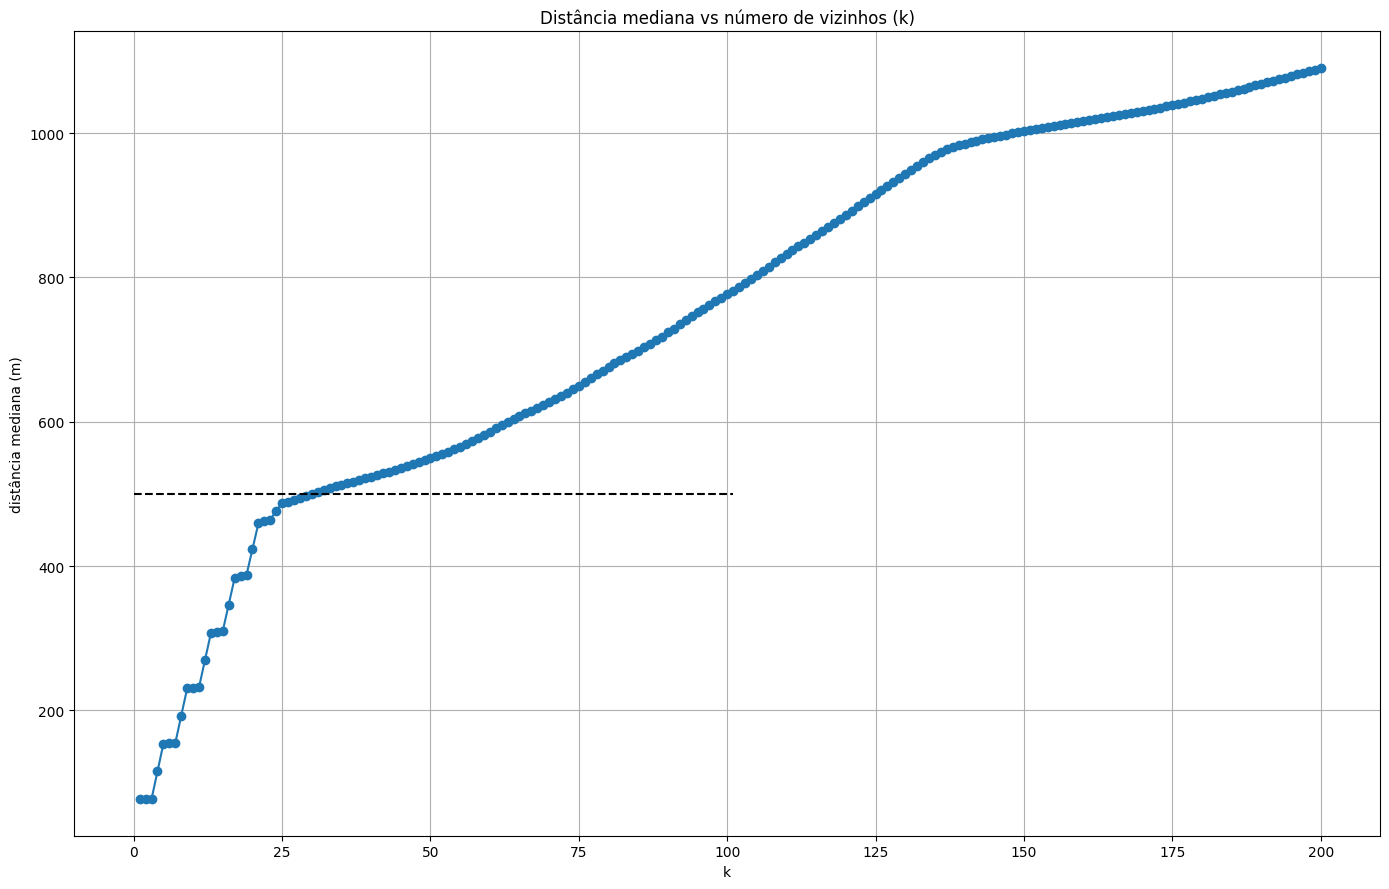

In [8]:
# Intervalo de k que queremos analisar
ks = np.arange(1, 201)  # 1 até 100
d_meds = []

for k in ks:
    # distâncias medianas aos k vizinhos mais próximos para cada ponto
    dist_k = vd.median_distance(coords, k_nearest=k)
    # uma única estatística global: mediana em todo o conjunto
    d_meds.append(np.median(dist_k))

d_meds = np.array(d_meds)

# Opcional: colocar em um DataFrame para inspeção numérica
df_knn = pd.DataFrame({"k": ks, "d_med_m": d_meds})
print(df_knn.head())
print(df_knn.tail())

import matplotlib.pyplot as plt
# assumindo que seu DataFrame se chama df
fig, ax = plt.subplots(figsize=(14,9))

ax.plot(df_knn["k"], df_knn["d_med_m"], marker="o", linestyle="-")
ax.set_xlabel("k")
ax.set_ylabel("distância mediana (m)")
ax.set_title("Distância mediana vs número de vizinhos (k)")
ax.hlines(y=500,xmin=0,xmax=101, linestyles='--', colors='black')
ax.grid(True)

plt.tight_layout()
plt.show()


In [9]:
# Espaçamento nominal entre linhas de voo (m)
line_spacing = 500.0

# df_knn já contém as colunas "k" e "d_med_m"

# 1) Variação absoluta da distância mediana entre k e k-1
df_knn["delta_d"] = df_knn["d_med_m"].diff()  # Na linha k=1 fica NaN

# 2) Variação relativa (taxa de crescimento)
df_knn["rel_delta"] = df_knn["delta_d"] / df_knn["d_med_m"].shift(1)

# 3) Diferença em relação aos 500 m (e valor absoluto)
df_knn["diff_to_500"] = df_knn["d_med_m"] - line_spacing
df_knn["abs_diff_500"] = df_knn["diff_to_500"].abs()

# Opcional: razão em relação ao espaçamento teórico
df_knn["ratio_to_500"] = df_knn["d_med_m"] / line_spacing

In [10]:
df_knn

,k,d_med_m,delta_d,rel_delta,diff_to_500,abs_diff_500,ratio_to_500
0,1,76.977047,NaN,NaN,-423.022953,423.022953,0.153954
1,2,77.113629,0.136581,0.001774,-422.886371,422.886371,0.154227
2,3,77.216963,0.103334,0.001340,-422.783037,422.783037,0.154434
3,4,115.527748,38.310785,0.496145,-384.472252,384.472252,0.231055
4,5,153.816648,38.288900,0.331426,-346.183352,346.183352,0.307633
...,...,...,...,...,...,...,...
195,196,1081.379547,2.255853,0.002090,581.379547,581.379547,2.162759
196,197,1083.515275,2.135728,0.001975,583.515275,583.515275,2.167031
197,198,1085.835404,2.320129,0.002141,585.835404,585.835404,2.171671
198,199,1088.006604,2.171200,0.002000,588.006604,588.006604,2.176013


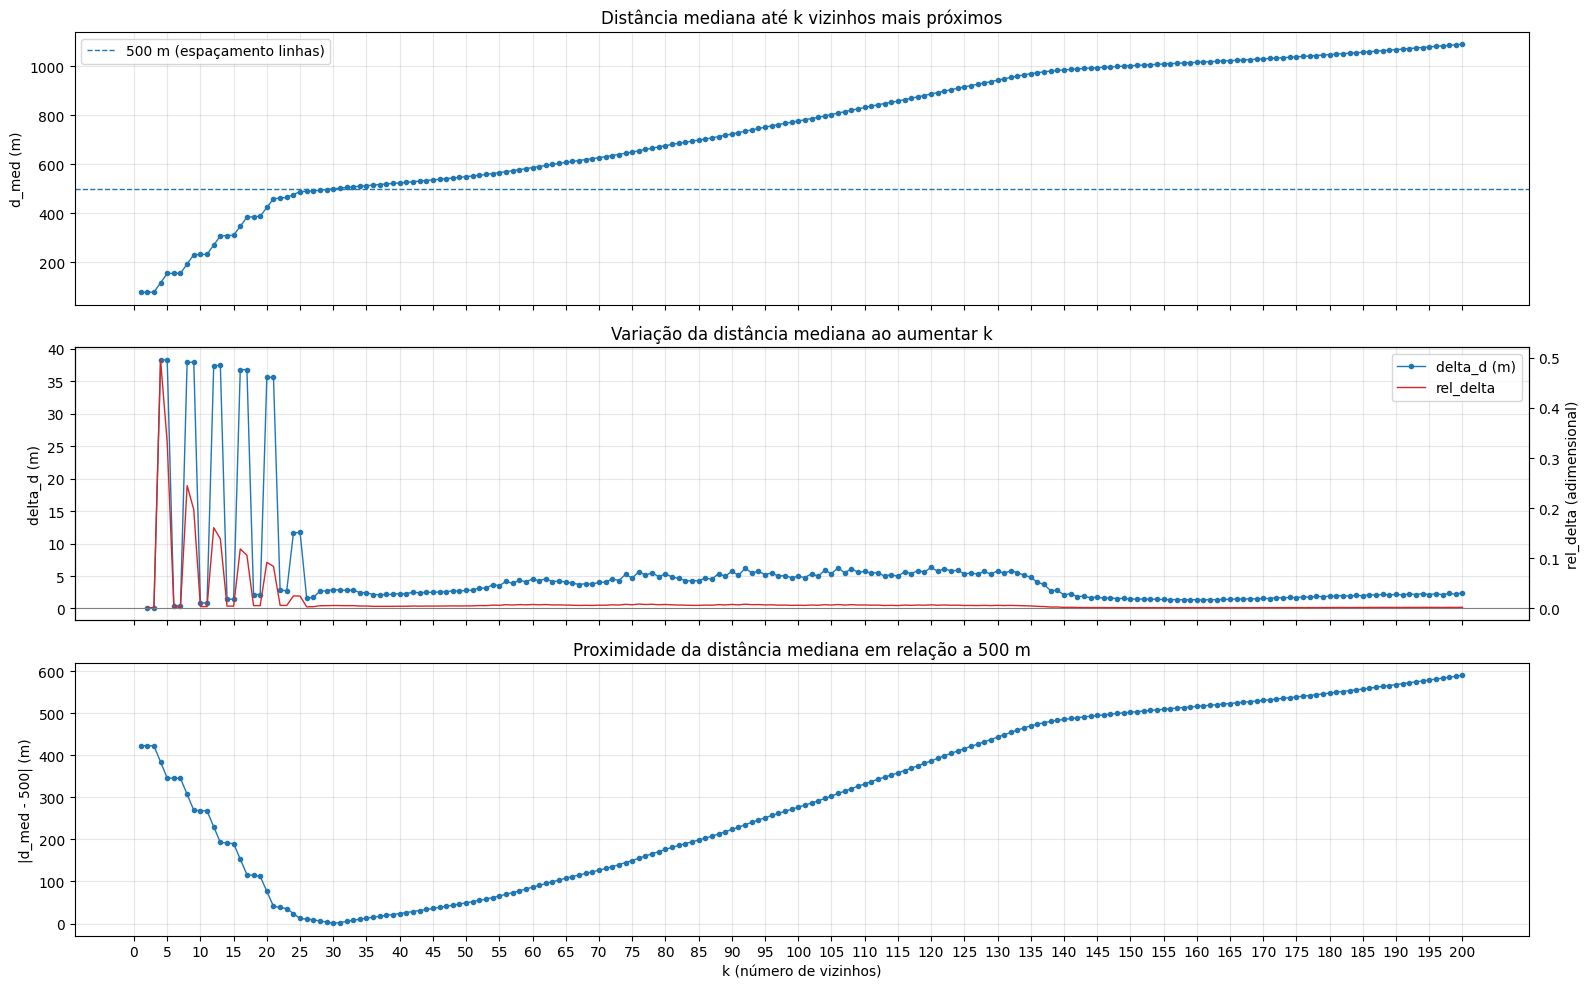

In [11]:
# Se quiser focar nos primeiros ks (por ex., até 100) para ficar mais legível:
k_max_plot = 500
df_plot = df_knn[df_knn["k"] <= k_max_plot].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 1) d_med_m vs k
ax0 = axes[0]
ax0.plot(df_plot["k"], df_plot["d_med_m"], marker=".", linewidth=1)
ax0.axhline(500, linestyle="--", linewidth=1, label="500 m (espaçamento linhas)")
ax0.set_ylabel("d_med (m)")
ax0.set_title("Distância mediana até k vizinhos mais próximos")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper left")


# 2) delta_d vs k + rel_delta no eixo secundário
ax1 = axes[1]
ax1.plot(df_plot["k"], df_plot["delta_d"], marker=".", linewidth=1, label="delta_d (m)")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_ylabel("delta_d (m)")
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_plot["k"], df_plot["rel_delta"], color="tab:red", linewidth=1, label="rel_delta")
ax1b.set_ylabel("rel_delta (adimensional)")

# Construir uma legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Variação da distância mediana ao aumentar k")

# 3) abs_diff_500 vs k (pode usar escala log)
ax2 = axes[2]
ax2.plot(df_plot["k"], df_plot["abs_diff_500"], marker=".", linewidth=1)
ax2.set_ylabel("|d_med - 500| (m)")
ax2.set_xlabel("k (número de vizinhos)")
ax2.set_title("Proximidade da distância mediana em relação a 500 m")
ax2.grid(True, alpha=0.3)
ax1.set_xticks(np.arange(0, 201, 5))

# opcional: escalar em log se ficar muito comprimido
# ax2.set_yscale("log")

plt.tight_layout()
plt.show()


# Trend

In [18]:
# Variável usada na decimação (pode ser qualquer coluna contínua sem NaN)
var = "kperc"  # troque se preferir outra variável
values = df_folha_lito[var].values

N_orig = values.size
print("N original:", N_orig)

# --------------------------------------------------------
# Loop sobre todos os k do df_knn
# --------------------------------------------------------
n_out_list = []

for _, row in df_knn.iterrows():
    spacing_k = row["d_med_m"]  # espaçamento em metros para este k
    reducer = vd.BlockReduce(reduction='median', spacing=spacing_k)
    coords_red, vals_red = reducer.filter((x, y), values)
    n_out_list.append(vals_red.size)

df_knn["n_out"] = n_out_list
df_knn["red_ratio"] = df_knn["n_out"] / N_orig  # fração de pontos que sobrevivem


N original: 39925


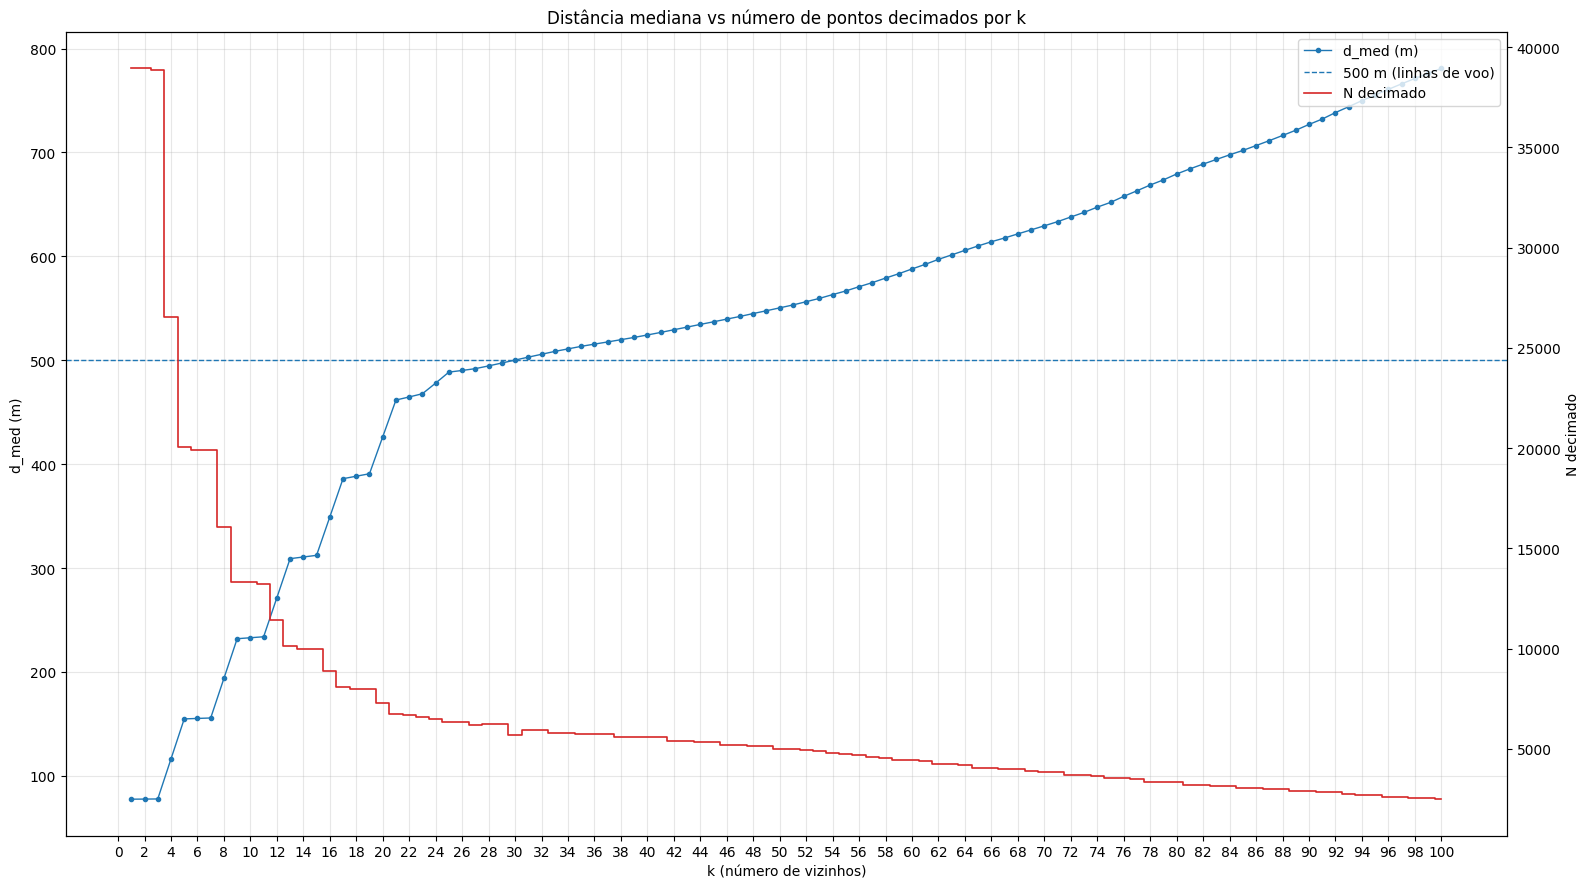

In [28]:
# Faixa de k para visualização
k_max_plot = 100
df_plot = df_knn[df_knn["k"] <= k_max_plot].copy()

fig, ax1 = plt.subplots(figsize=(16, 9))

# Eixo 1: d_med_m
ax1.plot(df_plot["k"], df_plot["d_med_m"], marker=".", linewidth=1,
         label="d_med (m)")
ax1.axhline(500, linestyle="--", linewidth=1, label="500 m (linhas de voo)")
ax1.set_xlabel("k (número de vizinhos)")
ax1.set_ylabel("d_med (m)")
ax1.grid(True, alpha=0.3)
k_min = df_plot["k"].min()
k_max = df_plot["k"].max()
ax1.set_xticks(np.arange(0, 101, 2))

# Eixo 2 (lado direito): n_out
ax2 = ax1.twinx()
ax2.step(df_plot["k"], df_plot["n_out"], where="mid",
         label="N decimado", linewidth=1.2, color="tab:red")
ax2.set_ylabel("N decimado")


# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Distância mediana vs número de pontos decimados por k")
plt.tight_layout()
plt.show()


In [32]:
%matplotlib inline
import pyproj
import ipywidgets as widgets
from IPython.display import display

var = "kperc"
values = df_folha_lito[var].values

N_orig = values.size
print("N original:", N_orig)

df_knn_k = df_knn.set_index("k")

# Fixar escala de cor
vmin, vmax = np.nanmin(values), np.nanmax(values)

# Slider de k
slider_k = widgets.IntSlider(
    value=30,
    min=1,
    max=100,
    step=1,
    description="k",
    continuous_update=True,
)

# Botão para ligar/desligar center_coordinates
toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs"  # opcional
)

out_plot = widgets.Output()

def update(k, center):
    with out_plot:
        out_plot.clear_output(wait=True)

        spacing = df_knn_k.loc[k, "d_med_m"]

        # center_coordinates controlado pelo botão
        reducer = vd.BlockReduce(reduction="median", spacing=spacing, center_coordinates=center)
        (coords_red, values_red) = reducer.filter((x, y), values)
        x_red, y_red = coords_red

        print(
            f"k={k}, spacing≈{spacing:.1f} m, "
            f"N decimado={values_red.size}, "
            f"center_coordinates={center}"
        )

        fig, ax = plt.subplots(figsize=(19, 8))
        # pontos originais
        ax.scatter(x, y, s=1, alpha=0.2, label="original")
        # pontos decimados
        sc = ax.scatter(
            x_red, y_red,
            s=8,
            c=values_red,
            vmin=vmin, vmax=vmax,
            edgecolor="k",
            linewidth=0.2,
            label=(
                f"decimado (k={k}, spacing≈{spacing:.0f} m, "
                f"center={center})"
            ),
        )

        cbar = plt.colorbar(sc, ax=ax, label=var)

        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(
            f"Pontos decimados por BlockReduce ({var}) "
            f"para a área da folha {df_folha_lito.folha_codigo.unique()}"
        )
        ax.axis("scaled")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

# ligar widgets à função update
ui = widgets.HBox([slider_k, toggle_center])
out_plot.clear_output()
widgets.interactive_output(update, {"k": slider_k, "center": toggle_center})

display(ui, out_plot)


N original: 39925


Output()

## Griding with Splines

In [38]:
var = "mdt"
#var = "uth_razao"
values = df_folha_lito[var].values
N_orig = values.size

print("N original:", N_orig)

# tabela k -> d_med_m
df_knn_k = df_knn.set_index("k")

# -------------------------------------------------------
# 1) Widgets: k e center_coordinates
# -------------------------------------------------------
slider_k = widgets.IntSlider(
    value=100,
    min=1,
    max=100,
    step=1,
    description="k",
    continuous_update=True,
)

toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs",
)

out_plot = widgets.Output()

# -------------------------------------------------------
# 2) Função de atualização: decimação + Spline + grid
# -------------------------------------------------------
def update(k, center):
    with out_plot:
        out_plot.clear_output(wait=True)

        # spacing a partir do k
        spacing = df_knn_k.loc[k, "d_med_m"]

        # decimação
        reducer = vd.BlockReduce(
            reduction="median",
            spacing=spacing,
            center_coordinates=center,
        )
        (coords_red, values_red) = reducer.filter((x, y), values)
        x_red, y_red = coords_red

        # ajuste do Spline nos dados decimados
        spline = vd.Spline(damping=1e-10)
        spline.fit((x_red, y_red), values_red)

        # resolução da grade (por ex. 1/5 do spacing de decimação)
        grid_spacing = spacing / 5.0

        # grid na região da folha (em x,y)
        grid = spline.grid(
            region=region_total,
            spacing=grid_spacing,
            data_names=[var],
        )

        print(
            f"k={k}, spacing_decim≈{spacing:.1f} m, "
            f"center_coordinates={center}, "
            f"N decimado={values_red.size}, "
            f"grid_spacing≈{grid_spacing:.1f} m"
        )

        # ---- Plot: campo interpolado + pontos decimados ----
        fig, ax = plt.subplots(figsize=(16, 12))

        # campo interpolado
        pc = ax.pcolormesh(
            grid.easting,
            grid.northing,
            grid[var],
            shading="auto",
        )
        cbar = plt.colorbar(pc, ax=ax, label=var)

        # pontos decimados
        ax.scatter(
            x_red, y_red,
            s=5,
            facecolor="none",
            edgecolor="k",
            linewidth=0.3,
            label="amostras decimadas",
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"Spline sobre dados decimados ({var})\n"
            f"folha {df_folha_lito.folha_codigo.unique()}, k={k}, spacing≈{spacing:.0f} m"
        )
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

# -------------------------------------------------------
# 3) Ligar widgets à função de update
# -------------------------------------------------------
ui = widgets.HBox([slider_k, toggle_center])
out_plot.clear_output()
widgets.interactive_output(update, {"k": slider_k, "center": toggle_center})

display(ui, out_plot)


N original: 39925


Output()

In [ ]:
## %matplotlib inline
import pyproj
import verde as vd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import warnings

# Opcional: suprimir FutureWarning específicos do Verde/Sklearn
warnings.filterwarnings(
    "ignore",
    message="The default scoring will change from R² to negative root mean squared error",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message="The mindist parameter of verde.Spline is no longer required",
    category=FutureWarning,
)

# -------------------------------------------
# 0) Dados já carregados
# -------------------------------------------
var = "eu"

x = df_folha_lito['x'].values
y = df_folha_lito['y'].values
values = df_folha_lito[var].values

df_knn_k = df_knn.set_index("k")

vmin, vmax = np.nanmin(values), np.nanmax(values)

print("N original:", values.size)
print("Região XY:", region_xy)

# Widgets
slider_k = widgets.IntSlider(
    value=30,
    min=1,
    max=100,
    step=1,
    description="k",
    continuous_update=True,
)

toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs",
)

out = widgets.Output()

def update(k, center):
    with out:
        out.clear_output(wait=True)
        spacing = df_knn_k.loc[k, "d_med_m"]

        # 1) Decimação
        reducer = vd.BlockReduce(
            reduction="mean",
            spacing=spacing,
            center_coordinates=center,
        )
        (coords_red, values_red) = reducer.filter((x, y), values)
        x_red, y_red = coords_red

        # 2) Fit do Spline
        spline = vd.Spline(damping=1e-10)
        spline.fit((x_red, y_red), values_red)

        pred_train = spline.predict((x_red, y_red))
        resid = values_red - pred_train
        rmse_train = np.sqrt(np.mean(resid**2))

        # 3) Cross-validation espacial com scoring explícito
        cv_spacing = spacing * 4.0
        cv = vd.BlockKFold(
            spacing=cv_spacing,
            n_splits=5,
            shuffle=True,
            random_state=0,
        )

        # (a) R² – scoring especificado explicitamente
        scores_r2 = vd.cross_val_score(
            vd.Spline(damping=1e-10),
            (x_red, y_red),
            values_red,
            cv=cv,
            scoring="r2",  # evita o aviso sobre mudança de padrão
        )
        r2_mean = np.mean(scores_r2)
        r2_std = np.std(scores_r2)

        # (b) RMSE – usar scoring de RMSE negativo nativo do Verde (>=1.8)
        scores_neg_rmse = vd.cross_val_score(
            vd.Spline(damping=1e-10),
            (x_red, y_red),
            values_red,
            cv=cv,
            scoring="neg_root_mean_squared_error",
        )
        rmse_scores = -scores_neg_rmse
        rmse_mean = np.mean(rmse_scores)
        rmse_std = np.std(rmse_scores)

        # 4) Grid
        grid_spacing = spacing / 5.0
        grid = spline.grid(
            region=region_xy,
            spacing=grid_spacing,
            data_names=[var],
        )

        # 5) Plots
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # (a) mapa interp.
        ax = axes[0]
        pc = ax.pcolormesh(
            grid.easting,
            grid.northing,
            grid[var],
            shading="auto",
            vmin=vmin,
            vmax=vmax,
        )
        fig.colorbar(pc, ax=ax, label=var)

        ax.scatter(
            x_red,
            y_red,
            s=8,
            facecolor="none",
            edgecolor="k",
            linewidth=0.3,
            label="amostras decimadas",
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"Spline ({var}) – folha {folha_id}\n"
            f"k={k}, spacing≈{spacing:.0f} m, center_coordinates={center}"
        )
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        # (b) histograma de resíduos
        ax2 = axes[1]
        ax2.hist(resid, bins='auto', alpha=0.7)
        ax2.axvline(0, linestyle="--", linewidth=1)
        ax2.set_title("Resíduos no conjunto decimado")
        ax2.set_xlabel("resíduo (obs − pred)")
        ax2.set_ylabel("contagem")

        plt.tight_layout()
        plt.show()

        # 6) Resumo numérico
        print(f"N original:  {values.size}")
        print(f"N decimado:  {values_red.size}")
        print(f"spacing (k={k}): {spacing:.1f} m | center_coordinates={center}")
        print('')
        print(
            f"Treino (decimado): "
            f"mean(res)={np.mean(resid):.4g}, "
            f"std(res)={np.std(resid):.4g}, "
            f"RMSE_treino={rmse_train:.4g}"
        )
        print(
            f"CV BlockKFold: spacing_cv={cv_spacing:.1f} m, "
            f"n_splits={len(scores_r2)}"
        )
        print(
            f"  R²  : mean={r2_mean:.4f}, std={r2_std:.4f}, "
            f"scores={np.array2string(scores_r2, precision=3)}"
        )
        print(
            f"  RMSE: mean={rmse_mean:.4f}, std={rmse_std:.4f}, "
            f"scores={np.array2string(rmse_scores, precision=3)}"
        )

ui = widgets.HBox([slider_k, toggle_center])
out.clear_output()
widgets.interactive_output(
    update,
    {"k": slider_k, "center": toggle_center},
)

display(ui, out)

In [47]:
def make_chain(spacing, center):
    return vd.Chain(
        [
            (
                "reduce",
                vd.BlockReduce(
                    reduction="mean",
                    spacing=spacing,
                    center_coordinates=center,
                ),
            ),
            ("spline", vd.Spline(damping=1e-10)),
        ]
    )

import pyproj
import verde as vd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import warnings

# Opcional: suprimir FutureWarning específicos do Verde/Sklearn
warnings.filterwarnings(
    "ignore",
    message="The default scoring will change from R² to negative root mean squared error",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message="The mindist parameter of verde.Spline is no longer required",
    category=FutureWarning,
)

# -------------------------------------------
# 0) Dados já carregados
# -------------------------------------------
var = "eu"

x = df_folha_lito['x'].values
y = df_folha_lito['y'].values
values = df_folha_lito[var].values

df_knn_k = df_knn.set_index("k")

vmin, vmax = np.nanmin(values), np.nanmax(values)

print("N original:", values.size)
print("Região XY:", region_total)

# Widgets
slider_k = widgets.IntSlider(
    value=200,
    min=1,
    max=200,
    step=1,
    description="k",
    continuous_update=True,
)

toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs",
)

out = widgets.Output()
def update(k, center):
    with out:
        out.clear_output(wait=True)
        spacing = df_knn_k.loc[k, "d_med_m"]
        coords = (x, y)

        # 1) Ajuste da cadeia (BlockReduce + Spline)
        chain = make_chain(spacing, center)
        chain.fit(coords, values)

        # Recuperar dados decimados para diagnóstico
        reducer = chain.named_steps["reduce"]
        (coords_red, values_red) = reducer.filter(coords, values)
        x_red, y_red = coords_red

        # Previsão e resíduos no conjunto decimado
        pred_train = chain.named_steps["spline"].predict(coords_red)
        resid = values_red - pred_train
        rmse_train = np.sqrt(np.mean(resid**2))

        # 2) Cross-validation espacial da cadeia completa
        cv_spacing = spacing * 4.0
        cv = vd.BlockKFold(
            spacing=cv_spacing,
            n_splits=5,
            shuffle=True,
            random_state=0,
        )

        # (a) R²
        scores_r2 = vd.cross_val_score(
            make_chain(spacing, center),
            coords,
            values,
            cv=cv,
            scoring="r2",
        )
        r2_mean = np.mean(scores_r2)
        r2_std = np.std(scores_r2)

        # (b) RMSE (neg_root_mean_squared_error → multiplicar por -1)
        scores_neg_rmse = vd.cross_val_score(
            make_chain(spacing, center),
            coords,
            values,
            cv=cv,
            scoring="neg_root_mean_squared_error",
        )
        rmse_scores = -scores_neg_rmse
        rmse_mean = np.mean(rmse_scores)
        rmse_std = np.std(rmse_scores)

        # 3) Grid com a cadeia ajustada
        grid_spacing = spacing / 5.0
        grid = chain.grid(
            region=region_total,
            spacing=grid_spacing,
            data_names=[var],
        )

        # 4) Plots
        fig, axes = plt.subplots(1, 2, figsize=(24, 9))

        # (a) mapa interp.
        ax = axes[0]
        pc = ax.pcolormesh(
            grid.easting,
            grid.northing,
            grid[var],
            shading="auto",
            vmin=vmin,
            vmax=vmax,
        )
        fig.colorbar(pc, ax=ax, label=var)

        ax.scatter(
            x_red,
            y_red,
            s=8,
            facecolor="none",
            edgecolor="k",
            linewidth=0.3,
            label="amostras decimadas",
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"Spline ({var}) – folha {df_folha_lito.folha_codigo.unique()}\n"
            f"k={k}, spacing≈{spacing:.1f} m, center_coordinates={center}"
        )
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        # (b) histograma de resíduos
        ax2 = axes[1]
        ax2.hist(resid, bins='auto', alpha=0.7)
        ax2.axvline(0, linestyle="--", linewidth=1)
        ax2.set_title("Resíduos no conjunto decimado")
        ax2.set_xlabel("resíduo (obs − pred)")
        ax2.set_ylabel("contagem")

        plt.tight_layout()
        plt.show()

        # 5) Resumo numérico
        print(f"N original:  {values.size}")
        print(f"N decimado:  {values_red.size}")
        print(f"spacing (k={k}): {spacing:.1f} m | center_coordinates={center}")
        print("")
        print(
            f"Treino (decimado): "
            f"mean(res)={np.mean(resid):.4g}, "
            f"std(res)={np.std(resid):.4g}, "
            f"RMSE_treino={rmse_train:.4g}"
        )
        print(
            f"CV BlockKFold (cadeia): spacing_cv={cv_spacing:.1f} m, "
            f"n_splits={len(scores_r2)}"
        )
        print(
            f"  R²  : mean={r2_mean:.4f}, std={r2_std:.4f}, "
            f"scores={np.array2string(scores_r2, precision=3)}"
        )
        print(
            f"  RMSE: mean={rmse_mean:.4f}, std={rmse_std:.4f}, "
            f"scores={np.array2string(rmse_scores, precision=3)}"
        )


ui = widgets.HBox([slider_k, toggle_center])
out.clear_output()
widgets.interactive_output(
    update,
    {"k": slider_k, "center": toggle_center},
)

display(ui, out)


N original: 39925
Região XY: [np.float64(555309.6753216047), np.float64(610674.9679028331), np.float64(9309054.656357162), np.float64(9336770.19411538)]


Output()